<a href="https://colab.research.google.com/github/realclovisworld/Neural_Networks/blob/main/Task_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK 6**

**(QN)** Design and implement a CNN model (with 4+ layers of convolutions) to classify multi-category image datasets. Use the concept of regularization and dropout while designing the CNN model. Use the Fashion MNIST datasets. Record the training accuracy and test accuracy corresponding to the following architectures:


*   Base Model
*   Model with L1 Regularization
*   Model with L2 Regularization
*   Model with Dropout
*   Model with both L2(or L1) and Dropout







**STEPS**


1. Import python liblaries for building and training the CNN
2. Load the Fashion MINST dataset into testing and training
3. Reshape the the image dta for the CNN model (batch_size,height,width,channels)
4. Perform Data type conversion and normalisation
5. Convert the integer labels to one-hot encoded vectors
6. Define the architecture of the Convolutional Neural Network (CNN) model using Keras's Sequential API.
7. Compile the model
8. Train the model
9. Evaluate the model on the test dataset
10. Generate predictions for the dataset and visualize







In [ ]:
#Import python liblaries for building and training the CNN
import keras
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D, Dropout
from keras.models import Sequential
from keras.regularizers import l1,l2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Loading the Fashion MNIST dataset into training and testing sets
(train_X,train_Y),(test_X,test_Y) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
#Reshape the the image dta for the CNN model (batch_size,height,width,channels)
train_X = train_X.reshape(-1,28,28,1)
test_X = test_X.reshape(-1,28,28,1)


In [ ]:
#Perform Data type conversion and normalisation
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X / 255
test_X = test_X / 255

In [ ]:
#Convert the integer labels to one-hot encoded vectors
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

In [ ]:
# Define the architecture of the Convolutional Neural Network (CNN) model using Keras's Sequential API.
#Base Model
model = Sequential()

model.add(Conv2D(256,(3,3),input_shape=(28,28,1)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64,(3,3),input_shape=(28,28,1),))
model.add(Activation('relu'))

model.add(Conv2D(32 ,(3,3)))
model.add(Activation('relu'))

model.add(Flatten())
model.add(Dense(64))
model.add(Dense(10))
model.add(Activation('softmax'))

In [ ]:
#Model with drop out of 0.25 and l2 regularizer
model =Sequential()

model.add(Conv2D(256,(3,3),input_shape=(28,28,1),kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(128,(3,3),kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64,(3,3),kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Conv2D(28,(3,3),kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(64))
model.add(Dense(10))
model.add(Activation('softmax'))


In [ ]:
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 26, 26, 256)    │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_50 (Activation)      │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 11, 11, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_51 (Activation)      │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 3, 3, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_52 (Activation)      │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 1, 1, 28)       │        16,156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_53 (Activation)      │ (None, 1, 1, 28)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_54 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,054 (1.49 MB)

 Trainable params: 390,054 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compile the model
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

In [ ]:
#Train the model
model.fit(train_X, train_Y_one_hot, batch_size=64, epochs=10)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.8039 - loss: 0.5302
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8812 - loss: 0.3292
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8969 - loss: 0.2795
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9086 - loss: 0.2479
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9168 - loss: 0.2247
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9254 - loss: 0.2010
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9320 - loss: 0.1808
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9370 - loss: 0.1684
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9442 - loss: 0.1507
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9485 - loss: 0.1375


In [ ]:
#Evaluate the model on the ttest dataset
test_loss,test_acc = model.evaluate(test_X, test_Y_one_hot)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9107 - loss: 0.2765
Test loss: 0.2765292823314667
Test accuracy: 0.9107000231742859


In [ ]:
#Generate pridictions for the dataset
predictions = model.predict(test_X)
predicted_classes = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


### Visualizing Predictions
Let's visualize some of the test images with their true and predicted labels.

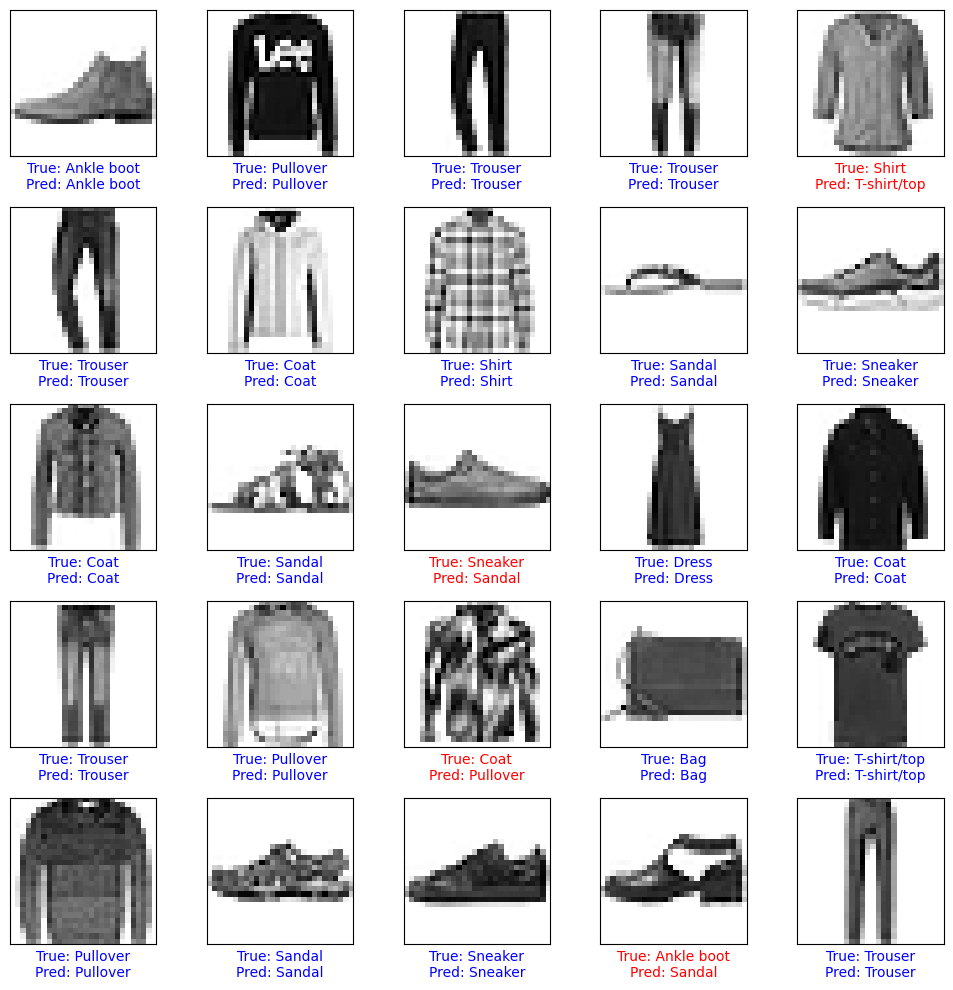

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_X[i].reshape(28,28), cmap=plt.cm.binary)
    true_label = np.argmax(test_Y_one_hot[i])
    predicted_label = predicted_classes[i]
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}", color=color)
plt.tight_layout()
plt.show()

*   Base Model = Test loss: 0.2765292823314667
Test accuracy: 0.9107000231742859

*   Model with L1 Regularization = Test loss: 2.7778444290161133
Test accuracy: 0.10000000149011612

*   Model with L2 Regularization = Test loss: 0.5594452023506165
Test accuracy: 0.8421000242233276

*   Model with Dropout = Test loss: 0.2723747193813324
Test accuracy: 0.9031000137329102

*   Model with both L2(or L1) and Dropout = Test loss: 0.64823317527771
Test accuracy: 0.8141999840736389